In [1]:
# Libraries

import os
import numpy as np
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torchvision.models import resnet50
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch.optim as optim
from tqdm import tqdm

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        
        self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out += identity  # Residual connection
        out = self.relu(out)
        return out

class UNet(nn.Module):
    def __init__(self, in_channels=1, num_classes=5):
        super(UNet, self).__init__()
        self.max_pool2d = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.down1 = ResidualBlock(in_channels, 64)
        self.down2 = ResidualBlock(64, 128)
        self.down3 = ResidualBlock(128, 256)
        self.down4 = ResidualBlock(256, 512)
        self.down5 = ResidualBlock(512, 1024)
        
        self.up_transpose1 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.up1 = ResidualBlock(1024, 512)
        self.up_transpose2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.up2 = ResidualBlock(512, 256)
        self.up_transpose3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.up3 = ResidualBlock(256, 128)
        self.up_transpose4 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.up4 = ResidualBlock(128, 64)
        
        self.out = nn.Conv2d(64, num_classes, kernel_size=1)
    
    def forward(self, x):
        down1 = self.down1(x)
        down2 = self.max_pool2d(down1)
        down2 = self.down2(down2)
        down3 = self.max_pool2d(down2)
        down3 = self.down3(down3)
        down4 = self.max_pool2d(down3)
        down4 = self.down4(down4)
        down5 = self.max_pool2d(down4)
        down5 = self.down5(down5)
        
        up1 = self.up_transpose1(down5)
        up1 = self.up1(torch.cat([down4, up1], dim=1))
        up2 = self.up_transpose2(up1)
        up2 = self.up2(torch.cat([down3, up2], dim=1))
        up3 = self.up_transpose3(up2)
        up3 = self.up3(torch.cat([down2, up3], dim=1))
        up4 = self.up_transpose4(up3)
        up4 = self.up4(torch.cat([down1, up4], dim=1))
        
        out = self.out(up4)
        return out


In [6]:
# Data Preprocessing

class MulticlassSegmentationDataset(Dataset):
    def __init__(self, ct_paths, liver_paths, aorta_paths, vessel_paths, tumor_paths, transform = None):
        self.ct_paths = ct_paths
        self.liver_paths = liver_paths
        self.aorta_paths = aorta_paths
        self.tumor_paths = tumor_paths
        self.vessel_paths = vessel_paths
        self.transform = transform

    def __len__(self):
        return len(self.ct_paths)

    def __getitem__(self, idx):

        # Load CT and Mask
        ct_image = np.load(self.ct_paths[idx])  
        liver_mask = np.load(self.liver_paths[idx])
        aorta_mask = np.load(self.aorta_paths[idx])
        tumor_mask = np.load(self.tumor_paths[idx])
        vessel_mask = np.load(self.vessel_paths[idx])

        # Normalize
        ct_image = ct_image / 255.0
        liver_mask = liver_mask / 255.0
        aorta_mask = aorta_mask / 255.0
        tumor_mask = tumor_mask / 255.0
        vessel_mask = vessel_mask / 255.0

        # Create a multiclass mask (5 classes: Background, Liver, Tumor, Aorta, Vessel)
        num_classes = 5
        multiclass_mask = np.zeros((ct_image.shape[0], ct_image.shape[1]), dtype=np.uint8)
        multiclass_mask.shape
        multiclass_mask[liver_mask >= 0.25] = 1  # Liver
        multiclass_mask[tumor_mask >= 0.25] = 2  # Tumor
        multiclass_mask[aorta_mask >= 0.25] = 3  # Aorta
        multiclass_mask[vessel_mask >= 0.25] = 4  # Vessels

        # print(multiclass_mask[200])
        # Expand dimensions for CT image (add channel dimension)
        ct_image = np.expand_dims(ct_image, axis=0)  # (1, H, W)

        # Convert to Tensors
        ct_image = torch.tensor(ct_image, dtype = torch.float32)
        multiclass_mask = torch.tensor(multiclass_mask, dtype = torch.long)
        # print(multiclass_mask[200])
        if self.transform is not None:
            ct_image = self.transform(ct_image)

        return ct_image, multiclass_mask

In [ ]:
# Retrieving Data and Splitting Test and Train

ROOT = r'/kaggle/input/hcc-nowindow/NOWINDOW/CT'
DIR = os.listdir(ROOT)
paths = [entry for entry in DIR if os.path.isdir(os.path.join(ROOT, entry))]
# print(paths)

# random.shuffle(paths)
paths_train = paths[:int(len(paths)*4//5)]
paths_test = paths[len(paths)*4//5:]




In [9]:
# Getting the train, val dataset

Images = []
LiverMask = []
AortaMask = []
VesselMask = []
TumorMask = []


ROOT_BASE = r'/kaggle/input/hcc-nowindow/NOWINDOW'
MasksType = ['LIVER', 'AORTA', 'VESSELS', 'TUMOR']

for direct in paths_train:
    Images.extend([os.path.join(ROOT, direct, entry) for entry in os.listdir(os.path.join(ROOT, direct))])
    LiverMask.extend([os.path.join(ROOT_BASE, 'LIVER', direct, entry) for entry in os.listdir(os.path.join(ROOT, direct))])
    AortaMask.extend([os.path.join(ROOT_BASE, 'AORTA', direct, entry) for entry in os.listdir(os.path.join(ROOT, direct))])
    VesselMask.extend([os.path.join(ROOT_BASE, 'VESSELS', direct, entry) for entry in os.listdir(os.path.join(ROOT, direct))])
    TumorMask.extend([os.path.join(ROOT_BASE, 'TUMOR', direct, entry) for entry in os.listdir(os.path.join(ROOT, direct))])
    
# Images, Mask
# trainImages, testImages, trainMasks, testMasks = train_test_split(Images, Mask, test_size = 0.2, random_state = 42)
trainImages, testImages, trainliverMasks, testliverMasks, trainaortaMasks, testaortaMasks, trainvesselMasks, testvesselMasks, traintumorMasks, testtumorMasks = train_test_split(Images, LiverMask, AortaMask, VesselMask, TumorMask, test_size=0.2, random_state=42)


In [11]:
dataset = MulticlassSegmentationDataset(trainImages, trainliverMasks, trainaortaMasks, trainvesselMasks, traintumorMasks)
batch_size = 8

train_dataset = MulticlassSegmentationDataset(trainImages, trainliverMasks, trainaortaMasks, trainvesselMasks, traintumorMasks)
test_dataset = MulticlassSegmentationDataset(testImages, testliverMasks, testaortaMasks, testvesselMasks, testtumorMasks)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)
device = "cuda" if torch.cuda.is_available() else "cpu"

unet_model = UNet(in_channels = 1, num_classes = 5).to(device)
optimizer = optim.Adam(unet_model.parameters(), lr = 1e-4)
weights = [0.4, 0.4,10.0, 20.0, 15.0]
class_weights = torch.FloatTensor(weights).cuda()

criterion = nn.CrossEntropyLoss(weight=class_weights)
# criterion = nn.CrossEntropyLoss()

In [13]:
TruTestImages = []
TruTestLiverMask = []
TruTestAortaMask = []
TruTestVesselMask = []
TruTestTumorMask = []

ROOT = r'/kaggle/input/hcc-nowindow/NOWINDOW/CT'
ROOT_BASE = r'/kaggle/input/hcc-nowindow/NOWINDOW'
MasksType = ['LIVER', 'AORTA', 'VESSELS', 'TUMOR']

for direct in paths_test:
    TruTestImages.extend([os.path.join(ROOT, direct, entry) for entry in os.listdir(os.path.join(ROOT, direct))])
    TruTestLiverMask.extend([os.path.join(ROOT_BASE, 'LIVER', direct, entry) for entry in os.listdir(os.path.join(ROOT, direct))])
    TruTestAortaMask.extend([os.path.join(ROOT_BASE, 'AORTA', direct, entry) for entry in os.listdir(os.path.join(ROOT, direct))])
    TruTestVesselMask.extend([os.path.join(ROOT_BASE, 'VESSELS', direct, entry) for entry in os.listdir(os.path.join(ROOT, direct))])
    TruTestTumorMask.extend([os.path.join(ROOT_BASE, 'TUMOR', direct, entry) for entry in os.listdir(os.path.join(ROOT, direct))])
    


true_test_dataset = MulticlassSegmentationDataset(TruTestImages, TruTestLiverMask, TruTestAortaMask, TruTestVesselMask, TruTestTumorMask)
true_test_dataloader = DataLoader(true_test_dataset, batch_size=batch_size, shuffle=True)

In [15]:
# Evalutaion

def dice_coefficient(pred_mask, true_mask, num_classes=5):
    """
    Calculate the Dice coefficient for each class.
    
    Args:
        pred_mask (torch.Tensor): Predicted mask of shape (H, W).
        true_mask (torch.Tensor): Ground truth mask of shape (H, W).
        num_classes (int): Number of classes in the segmentation task.
    
    Returns:
        List[float]: Dice coefficient for each class.
    """
    dice_scores = []
    for c in range(num_classes):
        pred_c = (pred_mask == c).float()
        true_c = (true_mask == c).float()
        
        intersection = torch.sum(pred_c * true_c)
        union = torch.sum(pred_c) + torch.sum(true_c)
        
        dice = (2.0 * intersection) / (union + 1e-6)  # Add small value to avoid division by zero
        dice_scores.append(dice.item())
    return dice_scores


In [16]:
def predict_mask(model, ct_image):
    """
    Generate predicted mask from the model.
    
    Args:
        model (torch.nn.Module): Trained U-Net model.
        ct_image (torch.Tensor): Input CT image of shape (1, H, W).
    
    Returns:
        torch.Tensor: Predicted mask of shape (H, W).
    """
    with torch.no_grad():
        model.eval()
        ct_image = ct_image.to(device)  # Move image to device
        pred = unet_model(ct_image.unsqueeze(0))  # Add batch dimension
        pred_mask = torch.argmax(pred, dim=1).squeeze(0)  # Get the class with max probability
    return pred_mask.cpu()


In [17]:
def evaluate_dice(model, dataset, num_classes=5):
    """
    Evaluate Dice coefficients for each class on a dataset.
    
    Args:
        model (torch.nn.Module): Trained U-Net model.
        dataset (Dataset): Dataset object.
        num_classes (int): Number of classes.
    
    Returns:
        dict: Average Dice scores for each class.
    """
    dice_scores_per_class = {c: [] for c in range(num_classes)}  # Initialize dictionary
    
    for idx in range(len(dataset)):
        ct_image, true_mask = dataset[idx]  # Get CT image and ground truth mask
        
        # Predict mask
        pred_mask = predict_mask(model, ct_image)
        
        # Calculate Dice coefficients
        dice_scores = dice_coefficient(pred_mask, true_mask, num_classes)
        for c in range(num_classes):
            dice_scores_per_class[c].append(dice_scores[c])
    
    # Average Dice scores across dataset
    avg_dice_scores = {c: sum(scores) / len(scores) for c, scores in dice_scores_per_class.items()}
    return avg_dice_scores


In [19]:
optimizer = optim.Adam(unet_model.parameters(), lr = 1e-3)

In [21]:
# Evaluate Dice coefficients
train_dice_scores = evaluate_dice(unet_model, train_dataset)
print("Train Dice Scores per Class:", train_dice_scores)

test_dice_scores = evaluate_dice(unet_model, test_dataset)
print("Val Dice Scores per Class:", test_dice_scores)

true_test_dice_scores = evaluate_dice(unet_model, true_test_dataset)
print("Test Dice Scores per Class:", true_test_dice_scores)

Train Dice Scores per Class: {0: 0.9882919082245775, 1: 0.21445580088481447, 2: 0.2082115675203189, 3: 0.08264588680484562, 4: 0.11427868639792647}
Val Dice Scores per Class: {0: 0.9880134177023516, 1: 0.2127588835357449, 2: 0.1842360715710089, 3: 0.06914351442069046, 4: 0.11528044882487197}
Test Dice Scores per Class: {0: 0.9793538700116997, 1: 0.19854846298736853, 2: 0.09273452306305821, 3: 0.04962542371972766, 4: 0.09621697599976001}


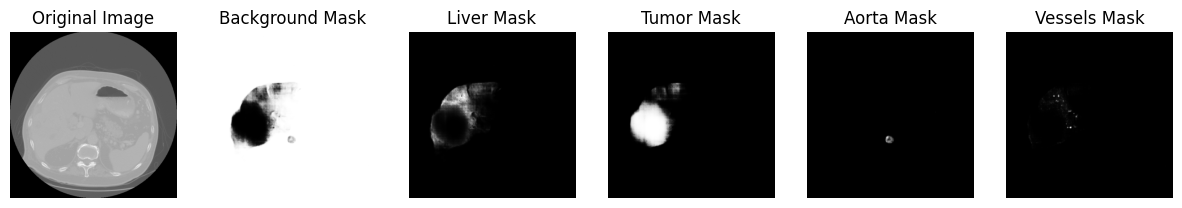

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import torch

def visualize_prediction(model, image_path, class_labels, threshold=0.5):
    """
    Visualize the original image and its predicted segmentation masks with class labels.
    
    Parameters:
    - model: The trained U-Net model.
    - image_path: Path to the NumPy file containing the test image.
    - class_labels: List of strings representing the class names (e.g., ['Liver', 'Tumor', 'Aorta', 'Vessels']).
    - threshold: Threshold for binarizing the predicted masks.
    """
    # Load the test image (NumPy array)
    image = np.load(image_path)
    image = image / 255.0  # Normalize the image
    
    # Add channel dimension if necessary (since it's a monochromatic image)
    image = np.expand_dims(image, axis=0)  # Shape: (1, H, W)
    
    # Convert image to PyTorch tensor and move it to the correct device
    image_tensor = torch.tensor(image, dtype=torch.float32).unsqueeze(0).to(device)  # Shape: (1, 1, H, W)
    
    # Set the model to evaluation mode
    model.eval()
    
    with torch.no_grad():
        # Get the model's prediction
        prediction = model(image_tensor)
        prediction = torch.softmax(prediction, dim=1)  # Apply softmax for multiclass probabilities
        prediction = prediction.squeeze().cpu().numpy()  # Remove batch dimension

    # print(prediction[1])
    # prediction *= 255.0
    # Initialize subplots with the number of classes + 1 (for original image)
    fig, axs = plt.subplots(1, len(class_labels) + 1, figsize=(15, 5))
    image *= 255.0
    # Original Image
    axs[0].imshow(image.squeeze(), cmap='gray')  # Display grayscale image
    axs[0].set_title('Original Image')
    axs[0].axis('off')

    # axs[1].imshow(prediction, cmap='gray')
    # axs[1].set_title(f'{class_label} Mask')  # Use class label in the title
    # axs[1].axis('off')
    # Plot each predicted mask for each class
    for class_idx, class_label in enumerate(class_labels):
        # Binarize the prediction for each class using the threshold
        # class_idx += 1
        predicted_mask = (prediction[class_idx]).astype(np.float32)
        # predicted_mask = (prediction[class_idx] >= threshold).astype(np.float32)
        
        # Plot the predicted mask
        predicted_mask *= 255.0
        # print((predicted_mask))
        axs[class_idx + 1].imshow(predicted_mask, cmap = 'gray')
        axs[class_idx + 1].set_title(f'{class_label} Mask')  # Use class label in the title
        axs[class_idx + 1].axis('off')

        # Print values for each mask (for debugging if needed)
        # print(f'Printing {class_label} Mask: {predicted_mask}')

    # Show the plot
    plt.show()

# Example usage:
# List of class labels corresponding to the masks
class_labels = ['Background','Liver', 'Tumor', 'Aorta', 'Vessels']  # Adjust as per your dataset

# Provide the path to the test NumPy image
test_image_path = '/kaggle/input/hcc-nowindow/NOWINDOW/CT/HCC56/HCC56_50.npy'

# Call the function to visualize prediction
visualize_prediction(unet_model, test_image_path, class_labels, threshold=0.25)


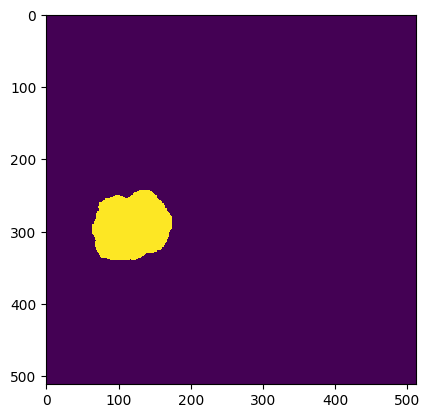

In [23]:
from matplotlib import pyplot as plt
data = np.load('/kaggle/input/hcc-nowindow/NOWINDOW/TUMOR/HCC56/HCC56_50.npy')
plt.imshow(data, interpolation='nearest')
plt.show()

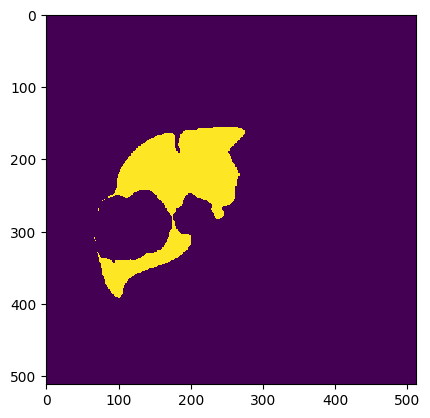

In [24]:
from matplotlib import pyplot as plt
data = np.load('/kaggle/input/hcc-nowindow/NOWINDOW/LIVER/HCC56/HCC56_50.npy')
plt.imshow(data, interpolation='nearest')
plt.show()

In [25]:
optimizer = optim.Adam(unet_model.parameters(), lr = 1e-4)
num_epochs = 12
for epoch in range(num_epochs):
    unet_model.train()
    running_loss = 0.0
    for i, (ct_images, masks) in enumerate(tqdm(train_dataloader)):
        ct_images = ct_images.to(device)
        masks = masks.to(device)
        # print(len(masks), len(ct_images))
        optimizer.zero_grad()
        outputs = unet_model(ct_images)
        # print(len(outputs[0][0]))
        # print(len(masks[0]))
        # print(outputs[0][0][0])
        # print(masks[0])
        loss = criterion(outputs, masks)
        # print(output)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_dataloader)}')
torch.save(unet_model.state_dict(), 'unet_multiclass_2.pth')

100%|██████████| 711/711 [12:57<00:00,  1.09s/it]


Epoch 1/12, Loss: 0.028816562664987187


100%|██████████| 711/711 [12:52<00:00,  1.09s/it]


Epoch 2/12, Loss: 0.02427386890758882


100%|██████████| 711/711 [12:58<00:00,  1.10s/it]


...

Epoch 10/12, Loss: 0.013915119348676763


100%|██████████| 711/711 [12:38<00:00,  1.07s/it]


Epoch 11/12, Loss: 0.013239816080470361


100%|██████████| 711/711 [12:37<00:00,  1.07s/it]

Epoch 12/12, Loss: 0.012621883985045485


In [26]:
# Evaluate Dice coefficients
train_dice_scores = evaluate_dice(unet_model, train_dataset)
print("Train Dice Scores per Class:", train_dice_scores)

test_dice_scores = evaluate_dice(unet_model, test_dataset)
print("Val Dice Scores per Class:", test_dice_scores)

true_test_dice_scores = evaluate_dice(unet_model, true_test_dataset)
print("Test Dice Scores per Class:", true_test_dice_scores)

Train Dice Scores per Class: {0: 0.998662883395508, 1: 0.6606013007409447, 2: 0.3229805090521324, 3: 0.1355609603427977, 4: 0.25554323556152087}
Val Dice Scores per Class: {0: 0.9977292248719856, 1: 0.6304782403365456, 2: 0.26753157149651907, 3: 0.1225383169955604, 4: 0.21240846573181305}
Test Dice Scores per Class: {0: 0.989507254089443, 1: 0.5801556112424793, 2: 0.10260761049952372, 3: 0.0463865345929045, 4: 0.16604151524641025}


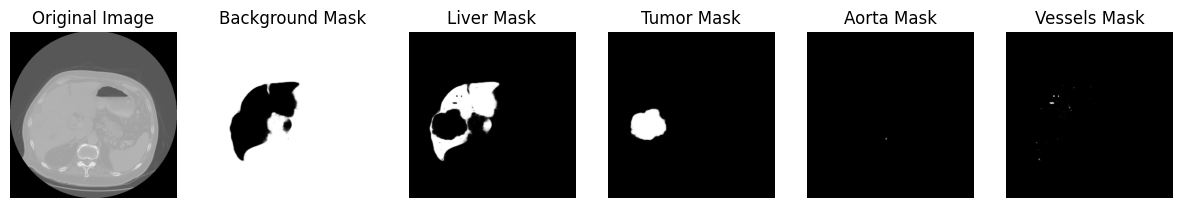

In [27]:
# Call the function to visualize prediction
visualize_prediction(unet_model, test_image_path, class_labels, threshold=0.25)

In [28]:
optimizer = optim.Adam(unet_model.parameters(), lr = 1e-5)
num_epochs = 8
for epoch in range(num_epochs):
    unet_model.train()
    running_loss = 0.0
    for i, (ct_images, masks) in enumerate(tqdm(train_dataloader)):
        ct_images = ct_images.to(device)
        masks = masks.to(device)
        # print(len(masks), len(ct_images))
        optimizer.zero_grad()
        outputs = unet_model(ct_images)
        # print(len(outputs[0][0]))
        # print(len(masks[0]))
        # print(outputs[0][0][0])
        # print(masks[0])
        loss = criterion(outputs, masks)
        # print(output)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_dataloader)}')
torch.save(unet_model.state_dict(), 'unet_multiclass_3.pth')

100%|██████████| 711/711 [12:40<00:00,  1.07s/it]


Epoch 1/8, Loss: 0.011968758910483093


100%|██████████| 711/711 [12:56<00:00,  1.09s/it]


Epoch 2/8, Loss: 0.011629137779935099


100%|██████████| 711/711 [13:20<00:00,  1.13s/it]


...

Epoch 6/8, Loss: 0.010980434542434728


100%|██████████| 711/711 [12:41<00:00,  1.07s/it]


Epoch 7/8, Loss: 0.01085229362526505


100%|██████████| 711/711 [12:39<00:00,  1.07s/it]

Epoch 8/8, Loss: 0.010730550492787537


In [29]:
# Evaluate Dice coefficients
train_dice_scores = evaluate_dice(unet_model, train_dataset)
print("Train Dice Scores per Class:", train_dice_scores)

test_dice_scores = evaluate_dice(unet_model, test_dataset)
print("Val Dice Scores per Class:", test_dice_scores)

true_test_dice_scores = evaluate_dice(unet_model, true_test_dataset)
print("Test Dice Scores per Class:", true_test_dice_scores)

Train Dice Scores per Class: {0: 0.9988048962417976, 1: 0.6699369340411718, 2: 0.3268152663573974, 3: 0.13672268003843807, 4: 0.28455402400174923}
Val Dice Scores per Class: {0: 0.9978030561227168, 1: 0.6378570867966961, 2: 0.2670026479001418, 3: 0.12137173441973542, 4: 0.2314001223453993}
Test Dice Scores per Class: {0: 0.9895659413550658, 1: 0.5870774394627262, 2: 0.0994655476996448, 3: 0.04898555286950333, 4: 0.1761342576289281}


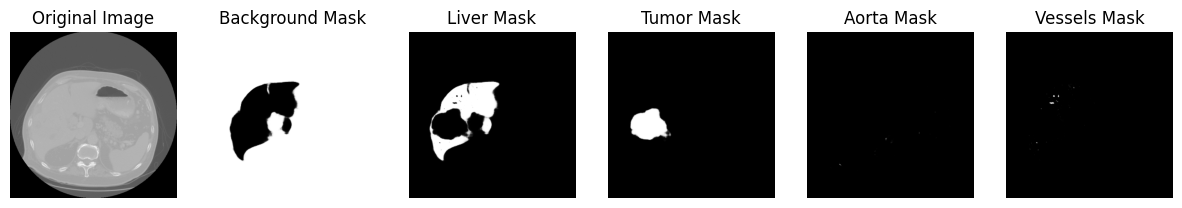

In [30]:
# Call the function to visualize prediction
visualize_prediction(unet_model, test_image_path, class_labels, threshold=0.25)

In [31]:
optimizer = optim.Adamax(unet_model.parameters(), lr = 1e-6)
num_epochs = 2
for epoch in range(num_epochs):
    unet_model.train()
    running_loss = 0.0
    for i, (ct_images, masks) in enumerate(tqdm(train_dataloader)):
        ct_images = ct_images.to(device)
        masks = masks.to(device)
        # print(len(masks), len(ct_images))
        optimizer.zero_grad()
        outputs = unet_model(ct_images)
        # print(len(outputs[0][0]))
        # print(len(masks[0]))
        # print(outputs[0][0][0])
        # print(masks[0])
        loss = criterion(outputs, masks)
        # print(output)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_dataloader)}')
torch.save(unet_model.state_dict(), 'unet_multiclass_fin.pth')

100%|██████████| 711/711 [12:45<00:00,  1.08s/it]


Epoch 1/2, Loss: 0.010691430894350148


100%|██████████| 711/711 [12:39<00:00,  1.07s/it]

Epoch 2/2, Loss: 0.01065273221703993


In [32]:
# Evaluate Dice coefficients
train_dice_scores = evaluate_dice(unet_model, train_dataset)
print("Train Dice Scores per Class:", train_dice_scores)

test_dice_scores = evaluate_dice(unet_model, test_dataset)
print("Val Dice Scores per Class:", test_dice_scores)

true_test_dice_scores = evaluate_dice(unet_model, true_test_dataset)
print("Test Dice Scores per Class:", true_test_dice_scores)

Train Dice Scores per Class: {0: 0.9988355492459524, 1: 0.6698479262031412, 2: 0.326111127987027, 3: 0.1365106725541798, 4: 0.2739067741213881}
Val Dice Scores per Class: {0: 0.997827875798597, 1: 0.6376999299907755, 2: 0.26799917574637894, 3: 0.12223775057811762, 4: 0.22393746549982718}
Test Dice Scores per Class: {0: 0.9895929306763515, 1: 0.5875347196465853, 2: 0.10148867767223176, 3: 0.04829863654143263, 4: 0.17120336021330965}


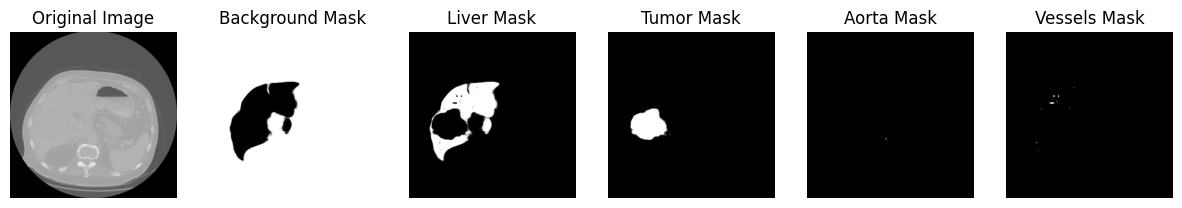

In [33]:
# Call the function to visualize prediction
visualize_prediction(unet_model, test_image_path, class_labels, threshold=0.25)